**数据读取与预处理**

数据集包含水泥、矿渣、水等 8 项混凝土组成成分特征，目标为混凝土抗压强度。使用StandardScaler对特征进行Z-score标准化，使各特征均值为0、方差 1，按照8:2随机划分训练集与测试集。

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


# 获取数据集
filename = 'Concrete_Data_Yeh.csv' 
df = pd.read_csv(filename)
print("--- 数据预览 ---")
print(df.head())
print(f"数据集形状: {df.shape}")
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)


# 随机划分数据集
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


#加载数据集
class ConcreteDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
    def __len__(self): return len(self.features)
    def __getitem__(self, idx): return self.features[idx], self.targets[idx]

train_loader = DataLoader(ConcreteDataset(X_train, y_train_raw), batch_size=16, shuffle=True)
test_loader = DataLoader(ConcreteDataset(X_test, y_test_raw), batch_size=16, shuffle=False)

--- 数据预览 ---
   cement   slag  flyash  water  superplasticizer  coarseaggregate  \
0   540.0    0.0     0.0  162.0               2.5           1040.0   
1   540.0    0.0     0.0  162.0               2.5           1055.0   
2   332.5  142.5     0.0  228.0               0.0            932.0   
3   332.5  142.5     0.0  228.0               0.0            932.0   
4   198.6  132.4     0.0  192.0               0.0            978.4   

   fineaggregate  age  csMPa  
0          676.0   28  79.99  
1          676.0   28  61.89  
2          594.0  270  40.27  
3          594.0  365  41.05  
4          825.5  360  44.30  
数据集形状: (1030, 9)


**模型构建**

构建四层全连接神经网络回归模型，输入维度为8，经过128、64、32神经元的隐藏层并使用 ReLU 激活函数引入非线性，输出1个节点表示强度预测值。

损失函数选用均方误差MSE，优化器采用Adam自适应学习率优化器。

训练共执行300轮，记录训练集与测试集损失，用于观察模型收敛状态与过拟合情况。

In [8]:
# 神经网络
class NeuralNet(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.layers(x)

model = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 300
train_loss_history = []
test_loss_history = []

print("\n--- 开始训练 ---")
for epoch in range(epochs):
    # 训练
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    train_loss = train_loss / len(train_loader.dataset)
    train_loss_history.append(train_loss)

    # 测试集损失
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)
    test_loss = test_loss / len(test_loader.dataset)
    test_loss_history.append(test_loss)

    if (epoch + 1) % 30 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] 训练Loss: {train_loss:.4f} | 测试Loss: {test_loss:.4f}")


--- 开始训练 ---
Epoch [30/300] 训练Loss: 33.1713 | 测试Loss: 42.3248
Epoch [60/300] 训练Loss: 21.9335 | 测试Loss: 34.3321
Epoch [90/300] 训练Loss: 16.5510 | 测试Loss: 32.2857
Epoch [120/300] 训练Loss: 13.7132 | 测试Loss: 31.4864
Epoch [150/300] 训练Loss: 12.6367 | 测试Loss: 32.4229
Epoch [180/300] 训练Loss: 11.1861 | 测试Loss: 34.3957
Epoch [210/300] 训练Loss: 9.3661 | 测试Loss: 32.3318
Epoch [240/300] 训练Loss: 10.2787 | 测试Loss: 33.0100
Epoch [270/300] 训练Loss: 9.2222 | 测试Loss: 29.8381
Epoch [300/300] 训练Loss: 9.0286 | 测试Loss: 32.8198


**模型评估**

使用均方误差MSE衡量预测误差大小，使用决定系数 R² 评估模型对数据的拟合程度，R² 越接近 1 说明模型拟合效果越好。

可视化两张图：训练与测试损失随迭代轮数的变化曲线；真实强度与预测强度的散点图。


测试集 MSE: 32.8198
测试集 R²(拟合度): 0.8726


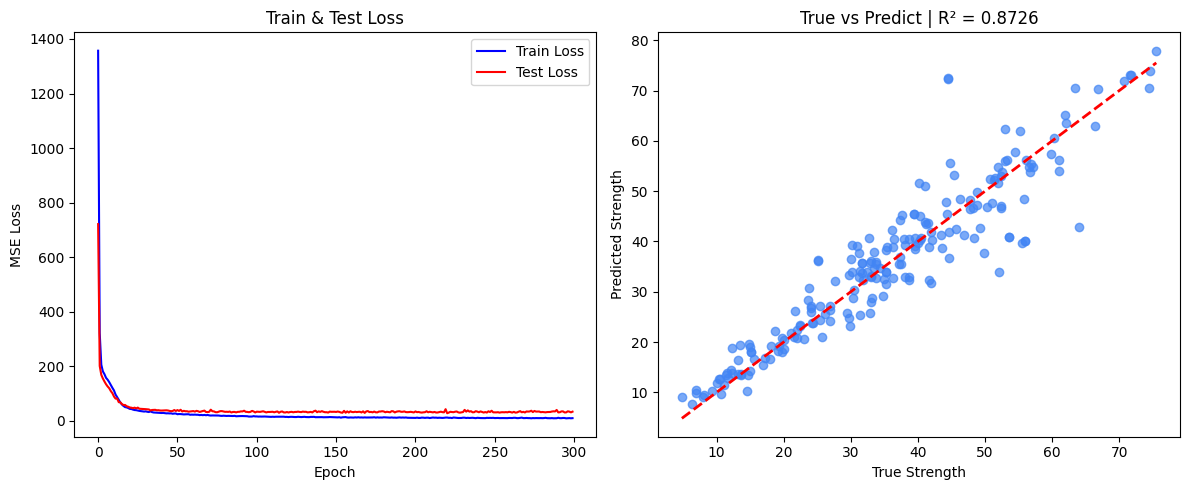

In [9]:
# 评估
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        y_pred.append(model(inputs).numpy())
        y_true.append(labels.numpy())

y_pred = np.vstack(y_pred)
y_true = np.vstack(y_true)

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\n测试集 MSE: {mse:.4f}")
print(f"测试集 R²(拟合度): {r2:.4f}")



plt.figure(figsize=(12, 5))

# 训练曲线
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss', color='blue')
plt.plot(test_loss_history, label='Test Loss', color='red')
plt.title('Train & Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

# 预测图
plt.subplot(1, 2, 2)
plt.scatter(y_true, y_pred, alpha=0.7, color='#4285F4')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('True Strength')
plt.ylabel('Predicted Strength')
plt.title(f'True vs Predict | R² = {r2:.4f}')
plt.tight_layout()
plt.show()